# **Homework 2**
### BUDT704- Data Processing and Analysis in Python-Fall 2024 maseri

Shruti Elango
(selango4)

In [ ]:
import numpy as np
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
worlddata = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/BUDT704- Data Processing and Analysis in Python-Fall 2024 maseri/Large Data Sets for Python/worlddata.csv')
worlddata.head()

,CountryName,CountryCode,IndicatorName,IndicatorCode,Year,Value
0,Arab World,ARB,"Adolescent fertility rate (births per 1,000 wo...",SP.ADO.TFRT,1960,1.335609e+02
1,Arab World,ARB,Age dependency ratio (% of working-age populat...,SP.POP.DPND,1960,8.779760e+01
2,Arab World,ARB,"Age dependency ratio, old (% of working-age po...",SP.POP.DPND.OL,1960,6.634579e+00
3,Arab World,ARB,"Age dependency ratio, young (% of working-age ...",SP.POP.DPND.YG,1960,8.102333e+01
4,Arab World,ARB,Arms exports (SIPRI trend indicator values),MS.MIL.XPRT.KD,1960,3.000000e+06


In [ ]:
Indicator_Values = worlddata.IndicatorName.unique()
Indicator_Values

array(['Adolescent fertility rate (births per 1,000 women ages 15-19)',
       'Age dependency ratio (% of working-age population)',
       'Age dependency ratio, old (% of working-age population)', ...,
       'Fish species, threatened', 'Mammal species, threatened',
       'Plant species (higher), threatened'], dtype=object)

In [ ]:
indicator_counts = worlddata['IndicatorName'].value_counts().head(60)
print(indicator_counts)

IndicatorName
Population, total                                                                          13484
Population growth (annual %)                                                               13442
Rural population (% of total population)                                                   13415
Urban population (% of total)                                                              13415
Urban population                                                                           13374
Rural population                                                                           13374
Urban population growth (annual %)                                                         13337
Surface area (sq. km)                                                                      13090
Land area (sq. km)                                                                         13086
Rural population growth (annual %)                                                         13061
Population densi

### **How do environmental indicators like CO2 emissions or land use and urbanization affect population growth**
Key Variables:
* Permanent cropland (% of land area)
* CO2 emissions (kt)
* Food production index (2004-2006 = 100)
* Surface area (sq. km)
* Arable land (% of land area)
* Crop production index
* Population growth (annual %)
* Urban population (% of total)  
* Rural population (% of total population)
* Population, total



In [ ]:
required_variables = ['Permanent cropland (% of land area)','CO2 emissions (kt)', 'Food production index (2004-2006 = 100)','Surface area (sq. km)',
'Arable land (% of land area)', 'Crop production index (2004-2006 = 100)', 'Population growth (annual %)', 'Urban population (% of total)', 'Rural population (% of total population)',
'Population, total', "Country Name"]
wd_E5 = worlddata[worlddata["IndicatorName"].isin(required_variables)]
wd_E5

,CountryName,CountryCode,IndicatorName,IndicatorCode,Year,Value
7,Arab World,ARB,CO2 emissions (kt),EN.ATM.CO2E.KT,1960,5.956399e+04
73,Arab World,ARB,"Population, total",SP.POP.TOTL,1960,9.249590e+07
75,Arab World,ARB,Rural population (% of total population),SP.RUR.TOTL.ZS,1960,6.871462e+01
79,Arab World,ARB,Urban population (% of total),SP.URB.TOTL.IN.ZS,1960,3.128538e+01
85,Caribbean small states,CSS,CO2 emissions (kt),EN.ATM.CO2E.KT,1960,5.878201e+03
...,...,...,...,...,...,...
5641516,Zimbabwe,ZWE,Population growth (annual %),SP.POP.GROW,2014,2.307451e+00
5641524,Zimbabwe,ZWE,"Population, total",SP.POP.TOTL,2014,1.524586e+07
5641641,Zimbabwe,ZWE,Rural population (% of total population),SP.RUR.TOTL.ZS,2014,6.749900e+01
5641656,Zimbabwe,ZWE,Surface area (sq. km),AG.SRF.TOTL.K2,2014,3.907600e+05


### Creating a new, organized dataset

In [ ]:
wd_pivot=pd.pivot_table(wd_E5, values='Value', index=['CountryName','CountryCode', 'Year'], columns=['IndicatorName'])
wd_pivot.rename(columns={'Permanent cropland (% of land area)':'Crop Land (% of area)','CO2 emissions (kt)':'CO2 Emissions (kt)', 'Food production index (2004-2006 = 100)': 'Food Production','Surface area (sq. km)': 'Land area (sq. km)',
'Arable land (% of land area)': 'Arable Land (% of land)', 'Crop production index (2004-2006 = 100)':'Crop production index', 'Population growth (annual %)': 'Population growth (annual %)', 'Urban population (% of total)':'Urban population (% of total)',
                        'Rural population (% of total population)':'Rural population (% of total)',
'Population, total': 'Population'}, inplace=True)

wd_pivot.reset_index(inplace=True)
wd_pivot

IndicatorName,CountryName,CountryCode,Year,Arable Land (% of land),CO2 Emissions (kt),Crop production index,Food Production,Crop Land (% of area),Population growth (annual %),Population,Rural population (% of total),Land area (sq. km),Urban population (% of total)
0,Afghanistan,AFG,1960,NaN,414.371,NaN,NaN,NaN,1.813677,8994793.0,91.779,NaN,8.221
1,Afghanistan,AFG,1961,11.717673,491.378,67.38,54.02,0.076586,1.874003,9164945.0,91.492,652860.0,8.508
2,Afghanistan,AFG,1962,11.794259,689.396,68.90,54.68,0.091903,1.932414,9343772.0,91.195,652860.0,8.805
3,Afghanistan,AFG,1963,11.870845,707.731,67.26,54.65,0.091903,1.989785,9531555.0,90.890,652860.0,9.110
4,Afghanistan,AFG,1964,11.947431,839.743,73.15,59.12,0.111816,2.046675,9728645.0,90.574,652860.0,9.426
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13578,Zimbabwe,ZWE,2010,10.339925,9028.154,99.55,96.05,0.258498,1.826380,13973897.0,66.804,390760.0,33.196
13579,Zimbabwe,ZWE,2011,10.856921,9860.563,105.67,100.19,0.258498,1.995816,14255592.0,66.985,390760.0,33.015
13580,Zimbabwe,ZWE,2012,10.339925,NaN,106.53,99.78,0.258498,2.150523,14565482.0,67.166,390760.0,32.834
13581,Zimbabwe,ZWE,2013,10.339925,NaN,108.19,97.96,0.258498,2.257867,14898092.0,67.346,390760.0,32.654


### Filter all Non-Countries out and remove all Nan values from the dataset to make it more clean.

In [ ]:
non_countries = [
    'Arab World', 'Caribbean small states', 'Central Europe and the Baltics',
    'East Asia & Pacific (all income levels)', 'East Asia & Pacific (developing only)',
    'Euro area', 'Europe & Central Asia (all income levels)',
    'Europe & Central Asia (developing only)', 'European Union',
    'Fragile and conflict affected situations', 'Heavily indebted poor countries (HIPC)',
    'High income', 'High income: OECD', 'High income: nonOECD',
    'Latin America & Caribbean (all income levels)',
    'Latin America & Caribbean (developing only)', 'Least developed countries: UN classification',
    'Low & middle income', 'Low income', 'Lower middle income',
    'Middle East & North Africa (all income levels)',
    'Middle East & North Africa (developing only)', 'Middle income',
    'North America', 'OECD members', 'Other small states',
    'Pacific island small states', 'Small states', 'South Asia',
    'Sub-Saharan Africa (all income levels)', 'Sub-Saharan Africa (developing only)',
    'Upper middle income', 'World'
]

df_filtered = wd_pivot[~wd_pivot['CountryName'].isin(non_countries)]

df = df_filtered.dropna(subset=['Crop Land (% of area)','CO2 Emissions (kt)',  'Food Production', 'Land area (sq. km)',
 'Arable Land (% of land)','CountryName','CountryCode', 'Year','Crop production index',  'Population growth (annual %)','Population','Urban population (% of total)', 'Rural population (% of total)'])
columns_to_convert = [
    'Year', 'Arable Land (% of land)', 'CO2 Emissions (kt)', 'Crop production index',
    'Food Production', 'Crop Land (% of area)', 'Population growth (annual %)',
    'Population', 'Rural population (% of total)', 'Land area (sq. km)',
    'Urban population (% of total)'
]

df[columns_to_convert] = df[columns_to_convert].apply(pd.to_numeric, errors='coerce')

df

<ipython-input-8-511d911c52e0>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[columns_to_convert] = df[columns_to_convert].apply(pd.to_numeric, errors='coerce')


IndicatorName,CountryName,CountryCode,Year,Arable Land (% of land),CO2 Emissions (kt),Crop production index,Food Production,Crop Land (% of area),Population growth (annual %),Population,Rural population (% of total),Land area (sq. km),Urban population (% of total)
1,Afghanistan,AFG,1961,11.717673,491.378,67.38,54.02,0.076586,1.874003,9164945.0,91.492,652860.0,8.508
2,Afghanistan,AFG,1962,11.794259,689.396,68.90,54.68,0.091903,1.932414,9343772.0,91.195,652860.0,8.805
3,Afghanistan,AFG,1963,11.870845,707.731,67.26,54.65,0.091903,1.989785,9531555.0,90.890,652860.0,9.110
4,Afghanistan,AFG,1964,11.947431,839.743,73.15,59.12,0.111816,2.046675,9728645.0,90.574,652860.0,9.426
5,Afghanistan,AFG,1965,11.947431,1008.425,75.72,61.96,0.114879,2.102528,9935358.0,90.250,652860.0,9.750
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13575,Zimbabwe,ZWE,2007,10.339925,9732.218,94.33,96.64,0.258498,1.285552,13297798.0,66.257,390760.0,33.743
13576,Zimbabwe,ZWE,2008,10.986170,7682.365,88.28,88.79,0.258498,1.475502,13495462.0,66.440,390760.0,33.560
13577,Zimbabwe,ZWE,2009,10.598423,8239.749,82.48,89.44,0.258498,1.657381,13720997.0,66.622,390760.0,33.378
13578,Zimbabwe,ZWE,2010,10.339925,9028.154,99.55,96.05,0.258498,1.826380,13973897.0,66.804,390760.0,33.196


## **Narrative**
* How do environmental indicators like CO2 emissions or land use and urbanization affect population growth?

* Key environmental indicators, such as CO2 emissions, land use, and urbanization, play a crucial role in shaping how populations grow and evolve over time.
* Understand the interconnectedness and how the variables evolve over time.
* Analyze the relationship between time and CO2 emissions, population, and urban population

# Variable Selection

In [ ]:
# import modules
import pandas as pd
import numpy as np

import statsmodels.api as sm


import matplotlib.pylab as plt
%matplotlib inline

import seaborn as sns
sns.set_style("whitegrid")

import sklearn.linear_model as sklm
from sklearn import metrics
from sklearn.model_selection import train_test_split

In [ ]:
predictors = ['CO2 Emissions (kt)', 'Land area (sq. km)', 'Crop Land (% of area)', 'Arable Land (% of land)',
              'Food Production', 'Crop production index', 'Urban population (% of total)', 'Rural population (% of total)']
outcome = 'Population'
df[predictors].info()

<class 'pandas.core.frame.DataFrame'>
Index: 8277 entries, 1 to 13579
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   CO2 Emissions (kt)             8277 non-null   float64
 1   Land area (sq. km)             8277 non-null   float64
 2   Crop Land (% of area)          8277 non-null   float64
 3   Arable Land (% of land)        8277 non-null   float64
 4   Food Production                8277 non-null   float64
 5   Crop production index          8277 non-null   float64
 6   Urban population (% of total)  8277 non-null   float64
 7   Rural population (% of total)  8277 non-null   float64
dtypes: float64(8)
memory usage: 582.0 KB


In [ ]:
X = pd.get_dummies(df[predictors], drop_first=True) # Converting object type variables into dummy
y = df[outcome]
train_X, valid_X, train_y, valid_y = train_test_split(X, y, test_size=0.4, random_state=1)

In [ ]:
!pip install dmba
from dmba import regressionSummary, exhaustive_search
from dmba import backward_elimination, forward_selection, stepwise_selection
from dmba import adjusted_r2_score, AIC_score, BIC_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 39.0 MB/s eta 0:00:00
Colab environment detected.


In [ ]:
#Linear regression functions
# training the model
def train_model(variables):
    model = sklm.LinearRegression()
    model.fit(train_X[variables], train_y)
    return model
#give quality score- adjusted R squared
def score_model(model, variables):
    pred_y = model.predict(train_X[variables])
    # we negate as score is optimized to be as low as possible
    return -adjusted_r2_score(train_y, pred_y, model)

In [ ]:
allVariables = train_X.columns
results = exhaustive_search(allVariables, train_model, score_model)
results

[{'n': 1,
  'variables': ['CO2 Emissions (kt)'],
  'score': -0.33892640682002084,
  'model': LinearRegression()},
 {'n': 2,
  'variables': ['CO2 Emissions (kt)', 'Land area (sq. km)'],
  'score': -0.3736508049684102,
  'model': LinearRegression()},
 {'n': 3,
  'variables': ['CO2 Emissions (kt)',
   'Land area (sq. km)',
   'Arable Land (% of land)'],
  'score': -0.40820418361270605,
  'model': LinearRegression()},
 {'n': 4,
  'variables': ['CO2 Emissions (kt)',
   'Land area (sq. km)',
   'Arable Land (% of land)',
   'Urban population (% of total)'],
  'score': -0.4314526656455461,
  'model': LinearRegression()},
 {'n': 5,
  'variables': ['CO2 Emissions (kt)',
   'Land area (sq. km)',
   'Crop Land (% of area)',
   'Arable Land (% of land)',
   'Urban population (% of total)'],
  'score': -0.4314781480133587,
  'model': LinearRegression()},
 {'n': 6,
  'variables': ['CO2 Emissions (kt)',
   'Land area (sq. km)',
   'Crop Land (% of area)',
   'Arable Land (% of land)',
   'Food Produc

In [ ]:
#how many variables should we select?
#increase number of variables- adjusted R increases

data = []
for result in results:
    model = result['model']
    variables = result['variables']
    AIC = AIC_score(train_y, model.predict(train_X[variables]), model)

    d = {'n': result['n'], 'r2adj': -result['score'], 'AIC': AIC}
    d.update({var: var in result['variables'] for var in allVariables})
    data.append(d)

searchresults=pd.DataFrame(data, columns=('n', 'r2adj', 'AIC') + tuple(sorted(allVariables)))
searchresults

,n,r2adj,AIC,Arable Land (% of land),CO2 Emissions (kt),Crop Land (% of area),Crop production index,Food Production,Land area (sq. km),Rural population (% of total),Urban population (% of total)
0,1,0.338926,196607.455430,False,True,False,False,False,False,False,False
1,2,0.373651,196340.503796,False,True,False,False,False,True,False,False
2,3,0.408204,196059.700644,True,True,False,False,False,True,False,False
3,4,0.431453,195861.676863,True,True,False,False,False,True,False,True
4,5,0.431478,195862.453173,True,True,True,False,False,True,False,True
5,6,0.431553,195862.797013,True,True,True,False,True,True,False,True
6,7,0.431473,195864.495190,True,True,True,True,True,True,False,True
7,8,0.431358,195866.495190,True,True,True,True,True,True,True,True


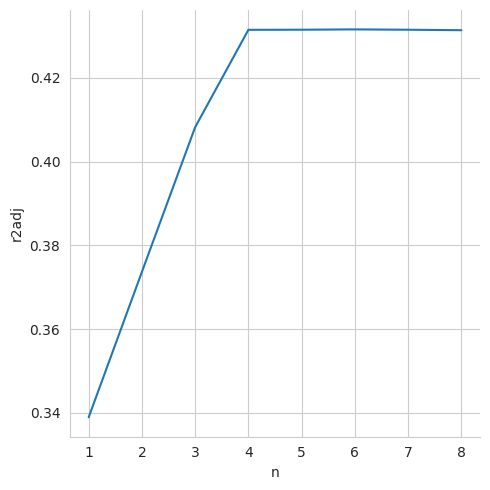

In [ ]:
sns.relplot(x="n", y="r2adj", data=searchresults, kind="line")

**Should select 4 variables**: Arable Land (% of land),	CO2 Emissions (kt),Land area (sq. km)	,	Urban population (% of total)

In [ ]:
# Split the data into training (60%), validation (20%), and test (20%) sets
from sklearn.model_selection import train_test_split

X = df[['Arable Land (% of land)', 'CO2 Emissions (kt)', 'Land area (sq. km)', 'Urban population (% of total)']]
y = df['Population']

# Split data into training and remaining sets (80% train, 20% remaining)
X_train, X_rem, y_train, y_rem = train_test_split(X, y, train_size=0.6, random_state=42)

# Split remaining data into validation and test sets (50% validation, 50% test)
X_valid, X_test, y_valid, y_test = train_test_split(X_rem, y_rem, test_size=0.5, random_state=42)

print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_valid.shape, y_valid.shape)
print("Test set shape:", X_test.shape, y_test.shape)

Training set shape: (4966, 4) (4966,)
Validation set shape: (1655, 4) (1655,)
Test set shape: (1656, 4) (1656,)


In [ ]:
model=sklm.LinearRegression()
model.fit(X, y)

LinearRegression()

In [ ]:

print('Intercept:', model.intercept_)
print('Arable Land (% of land):', model.coef_[0])
print('CO2 Emissions (kt):', model.coef_[1])
print('Land area (sq. km):', model.coef_[2])
print('Urban population (% of total):', model.coef_[3])

Intercept: 18615235.51348652
Arable Land (% of land): 1362293.653289509
CO2 Emissions (kt): 101.47773058768921
Land area (sq. km): 16.042849664952342
Urban population (% of total): -668400.6838279815


In [ ]:
# Fit the linear regression model
model = sklm.LinearRegression()
model.fit(X_train, y_train)

# Print the model coefficients
print('Intercept:', model.intercept_)
print('Coefficients:', model.coef_)

Intercept: 17466954.453467593
Coefficients: [ 1.47079802e+06  1.01420828e+02  1.70631770e+01 -6.78807939e+05]


In [ ]:
# Predict on the training data
train_predictions = model.predict(X_train)
train_predictions

array([27752409.0211979 , 22909346.76152956, -8670926.40547261, ...,
       48371631.81283743, 16319203.23166145, 10400846.72295773])

In [ ]:

from statsmodels.tools.eval_measures import rmse

# Calculate RMSE on the training data
train_rmse = rmse(y_train, train_predictions)
print(f"RMSE on training data: {train_rmse}")

RMSE on training data: 82417698.3618053


In [ ]:

# Predict on the validation data
valid_predictions = model.predict(X_valid)
print(valid_predictions[:10])
# Calculate RMSE on the validation data
valid_rmse = rmse(y_valid, valid_predictions)
print(f"RMSE on validation data: {valid_rmse}")

[ 2.71694345e+07  1.84974224e+08  1.59701563e+06  1.99929902e+07
  5.56092901e+07  7.49959370e+06  3.58688627e+06  1.24514350e+08
  1.42748166e+07 -3.90553397e+07]
RMSE on validation data: 76066897.6493638


## Modeling: Linear Regressions

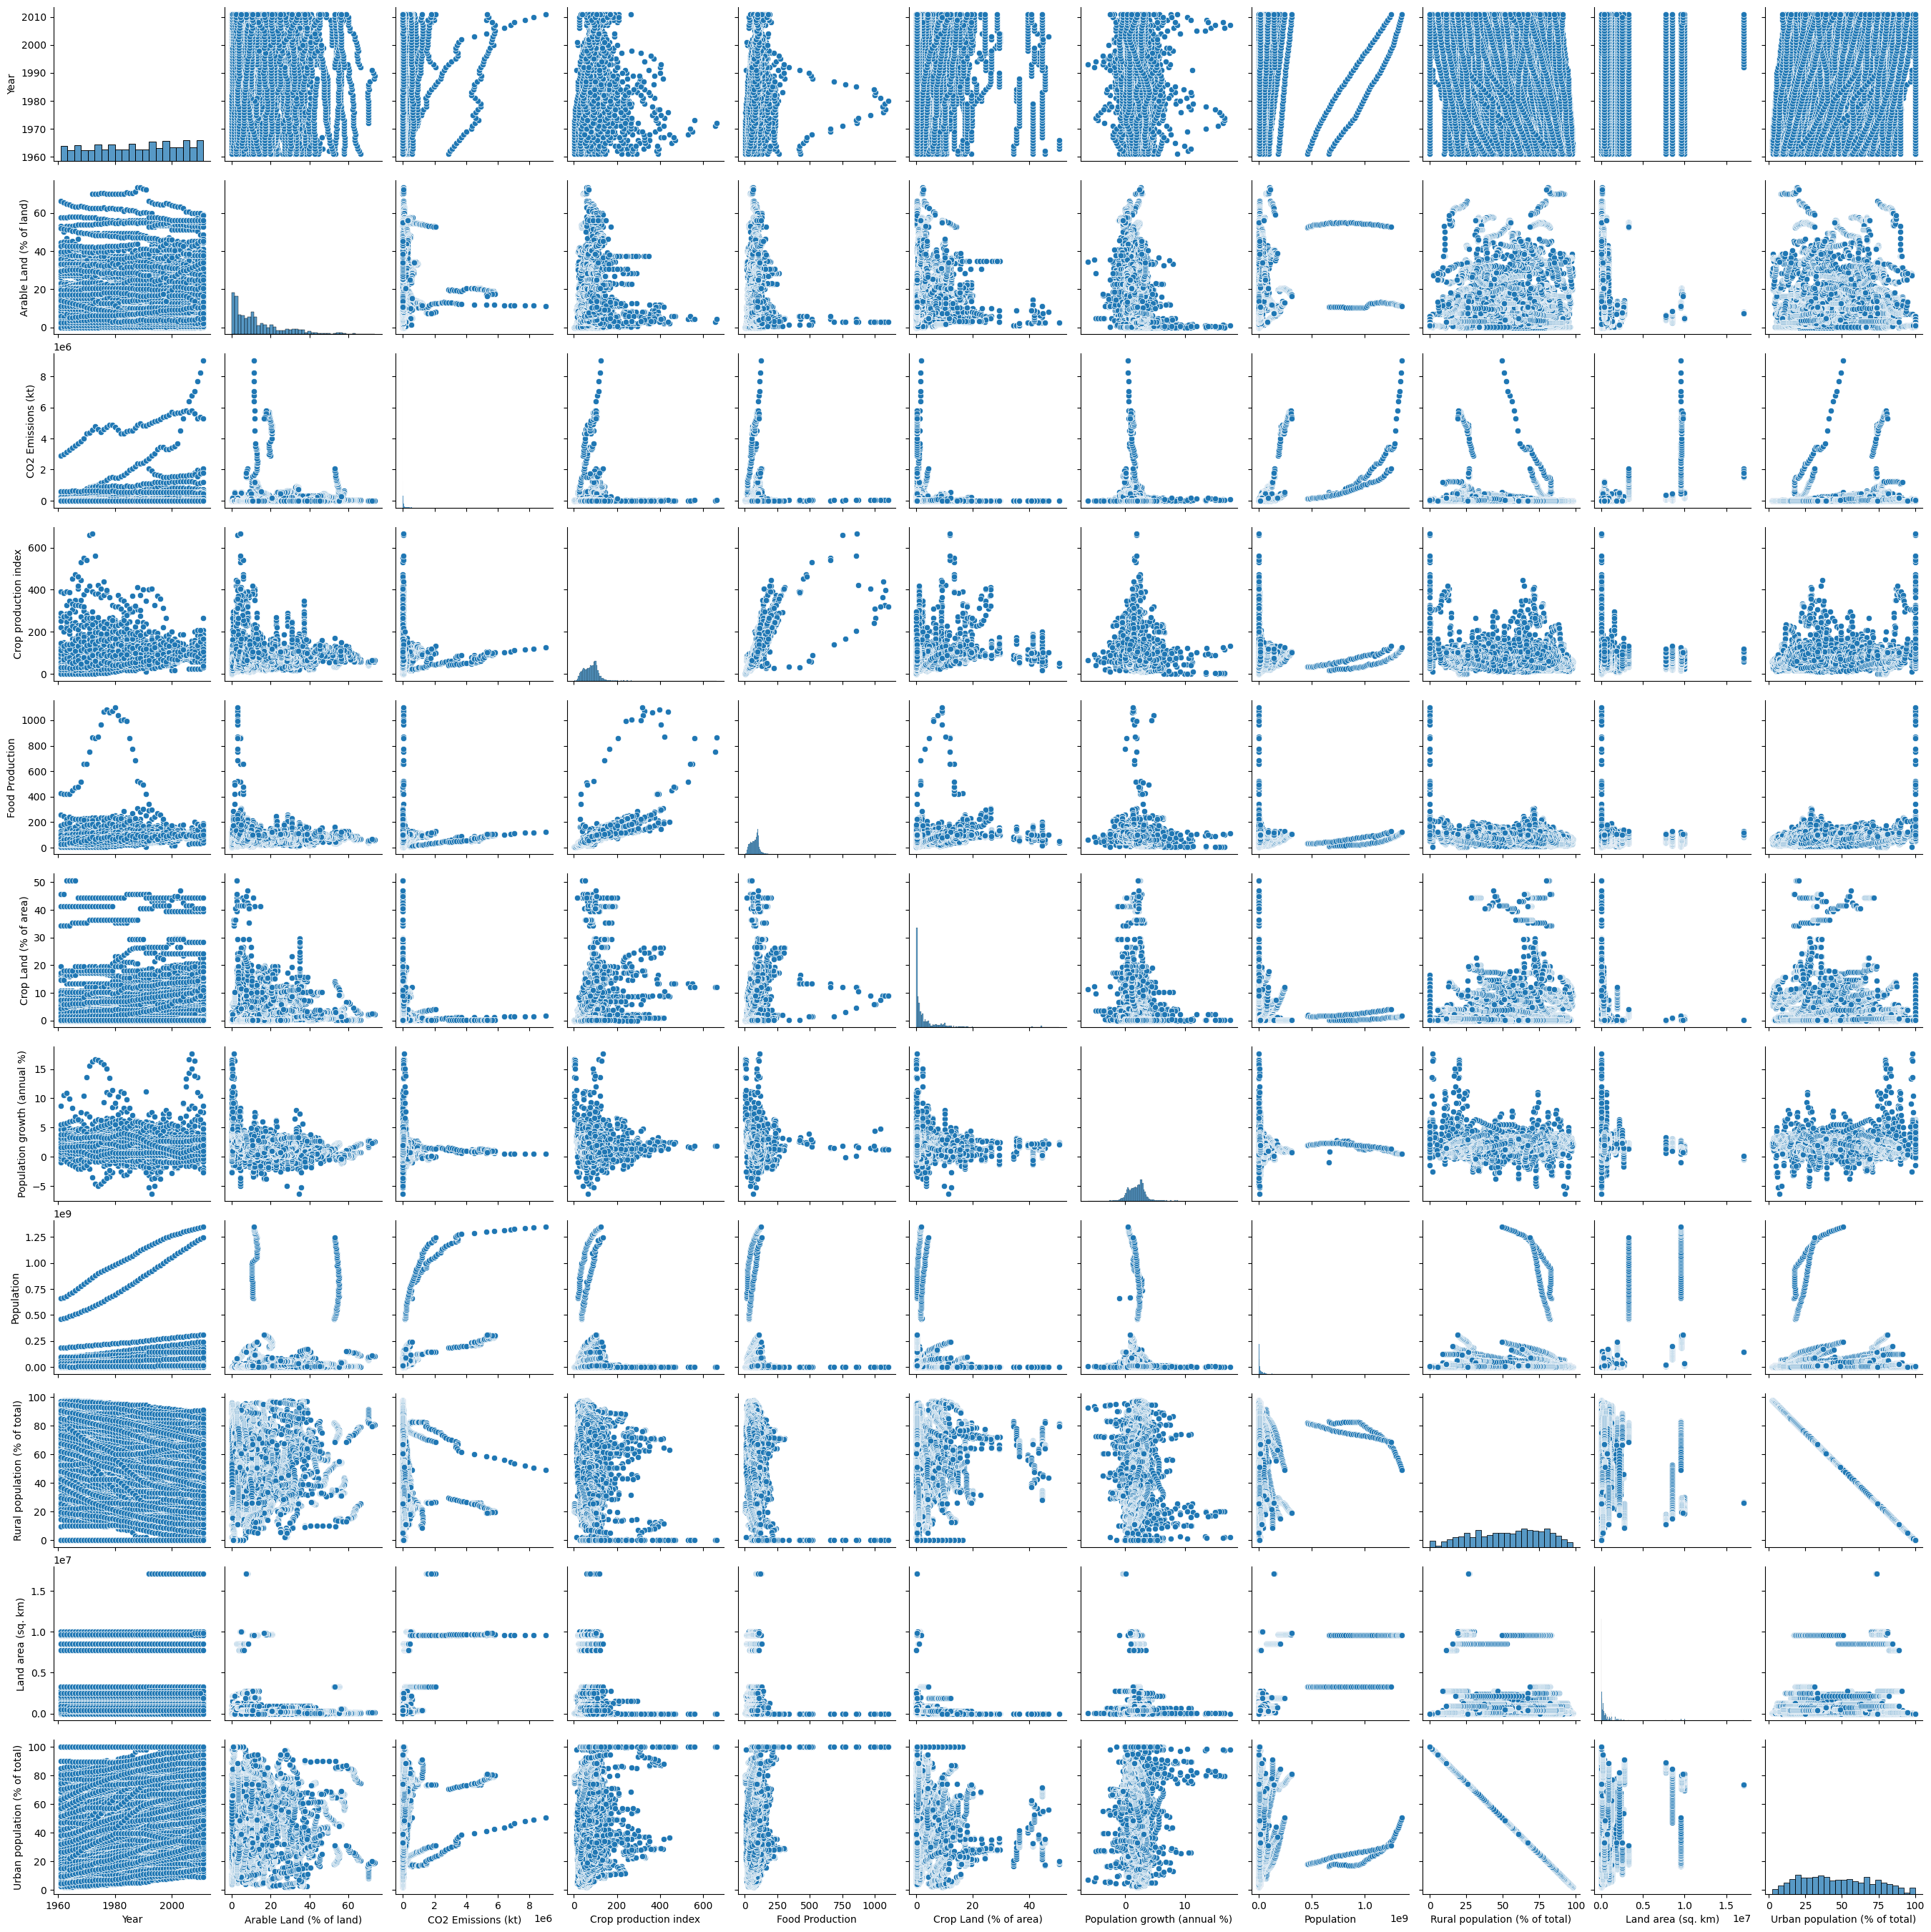

In [ ]:
sns.pairplot(data=df)

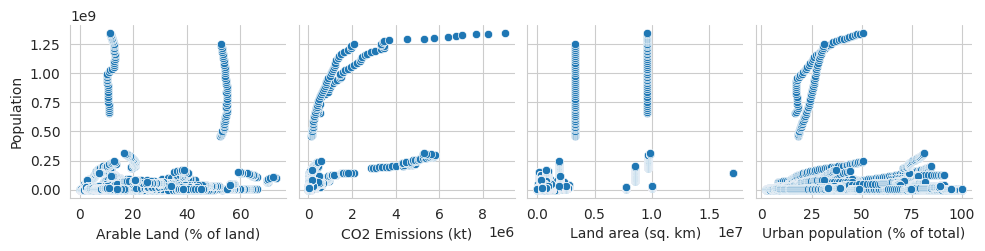

In [ ]:
sns.pairplot(data=df, y_vars=['Population'], x_vars=['Arable Land (% of land)', 'CO2 Emissions (kt)', 'Land area (sq. km)', 'Urban population (% of total)'])

In [ ]:
df[['Population','Arable Land (% of land)', 'CO2 Emissions (kt)', 'Land area (sq. km)', 'Urban population (% of total)']].corr()

IndicatorName,Population,Arable Land (% of land),CO2 Emissions (kt),Land area (sq. km),Urban population (% of total)
IndicatorName,,,,,
Population,1.000000,0.183452,0.596131,0.495859,-0.045967
Arable Land (% of land),0.183452,1.000000,0.088369,-0.093611,-0.000393
CO2 Emissions (kt),0.596131,0.088369,1.000000,0.596508,0.153714
Land area (sq. km),0.495859,-0.093611,0.596508,1.000000,0.125424
Urban population (% of total),-0.045967,-0.000393,0.153714,0.125424,1.000000


<Axes: xlabel='IndicatorName', ylabel='IndicatorName'>

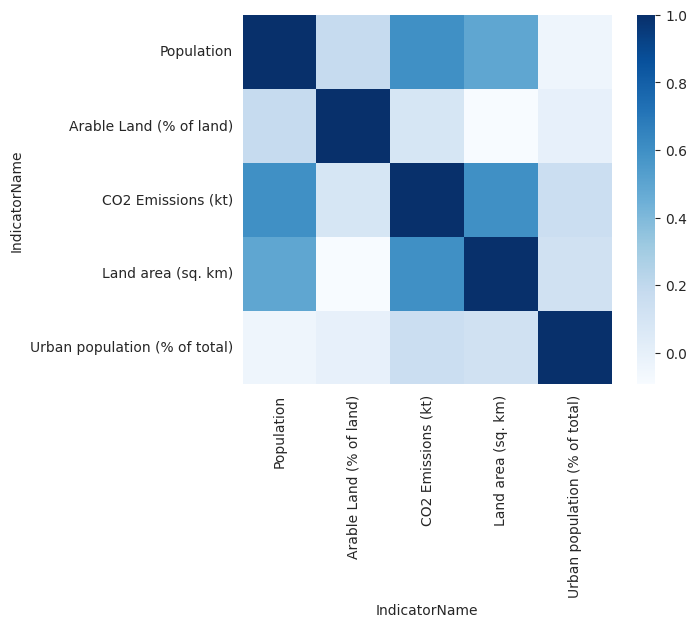

In [ ]:
#correlation heatmap
corrmat = df[['Population', 'Arable Land (% of land)', 'CO2 Emissions (kt)', 'Land area (sq. km)', 'Urban population (% of total)']].corr()
sns.heatmap(corrmat, square = True, cmap="Blues")

## Regression Analysis with Stats Model

In [ ]:
# import modules
import statsmodels.api as sm
import matplotlib.pylab as plt
%matplotlib inline

import seaborn as sns
sns.set_style("whitegrid")

import sklearn.linear_model as sklm
from sklearn import metrics
from sklearn.model_selection import train_test_split

In [ ]:
y=df['Population']
X=df[[ 'Arable Land (% of land)', 'CO2 Emissions (kt)', 'Land area (sq. km)', 'Urban population (% of total)']]
X=sm.add_constant(X)
model1 = sm.OLS(y, X)
results1 = model1.fit()
results1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Population   R-squared:                       0.435
Model:                            OLS   Adj. R-squared:                  0.434
Method:                 Least Squares   F-statistic:                     1590.
Date:                Wed, 30 Oct 2024   Prob (F-statistic):               0.00
Time:                        18:06:28   Log-Likelihood:            -1.6266e+05
No. Observations:                8277   AIC:                         3.253e+05
Df Residuals:                    8272   BIC:                         3.254e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
=================================================================================================
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const                          1.862e+07   2.22e+06      8.378      0.000    1.43e+07     2.3e+07
Arable Land (% of land)        1.362e+06   6.82e+04     19.975      0.000    1.23e+06     1.5e+06
CO2 Emissions (kt)              101.4777      2.391     42.440      0.000      96.791     106.165
Land area (sq. km)               16.0428      0.638     25.157      0.000      14.793      17.293
Urban population (% of total) -6.684e+05   3.79e+04    -17.630      0.000   -7.43e+05   -5.94e+05
==============================================================================
Omnibus:                     8785.879   Durbin-Watson:                   0.034
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           971799.558
Skew:                           5.192   Prob(JB):                         0.00
Kurtosis:                      55.058   Cond. No.                     4.82e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.82e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Variables not significant for regression p>0.05

In [ ]:
pvalues = results1.pvalues
insignificant_vars = pvalues[pvalues > 0.05].index
print(f'insignificant_vars are {insignificant_vars}')

insignificant_vars are Index([], dtype='object')


Crop production index, Food Production, Crop Land (% of area) are **insignificant**

## Check for Multicollinearity

In [ ]:
#i Multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
# VIF dataframe
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns

# calculating VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
vif_data

,feature,VIF
0,const,5.942139
1,Arable Land (% of land),1.042848
2,CO2 Emissions (kt),1.620390
3,Land area (sq. km),1.608825
4,Urban population (% of total),1.026100


VIF > 4 indicates the presence of multicolinearity.

In [ ]:
x_drop= vif_data[vif_data['feature']!= 'const']
x_drop

,feature,VIF
1,Arable Land (% of land),1.042848
2,CO2 Emissions (kt),1.620390
3,Land area (sq. km),1.608825
4,Urban population (% of total),1.026100


Normality of residuals

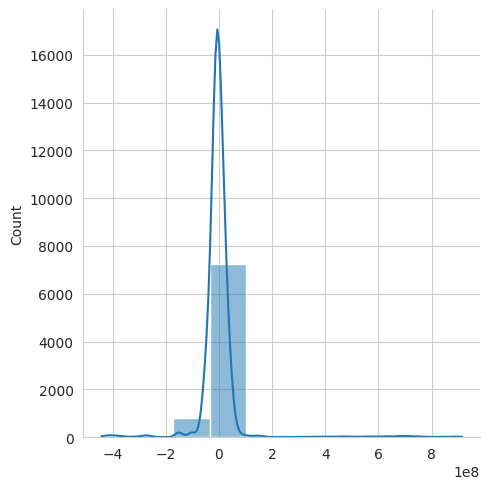

In [ ]:

residuals = results1.resid
sns.displot(residuals, bins=10, kde=True, kind="hist")

Q-Q Plot

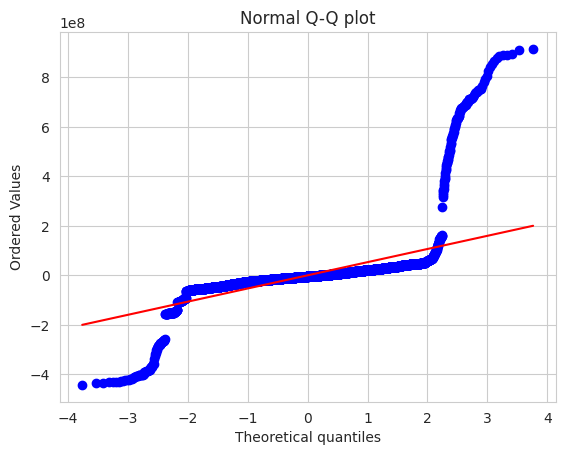

Shapiro-Wilk test p-value: 1.3614863617827752e-96


/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8277.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
# Check for Normality of Residuals
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Normal Q-Q plot")
plt.show()

# Shapiro-Wilk test for normality
_, p_value_shapiro = stats.shapiro(residuals)
print(f"Shapiro-Wilk test p-value: {p_value_shapiro}")

The **null-hypothesis** for Shapiro-Wilk test is that **residual is normally distributed.**

In the above, we see that the p-value is lower than 0.05. Thus, we reject the null hyposthesis and conclude that the **residual is not normally distributed.**

## Fixing Non-Normality - Achieving normality with Box-Cox transformation

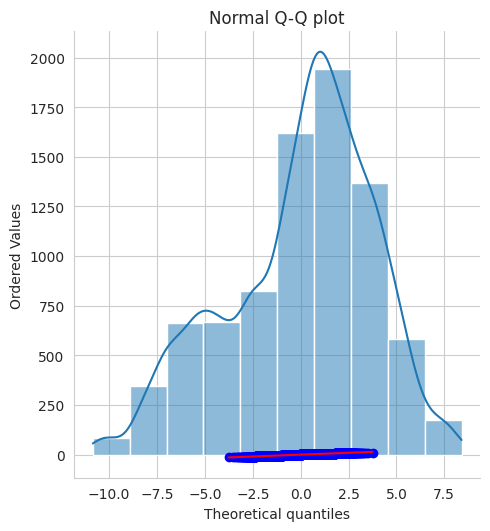

Shapiro-Wilk test p-value (Box-Cox transformed): 5.749588567361057e-37


/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8277.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
from scipy.stats import boxcox
y = df['Population']
X = df[[ 'Arable Land (% of land)', 'CO2 Emissions (kt)', 'Land area (sq. km)', 'Urban population (% of total)']]
X = sm.add_constant(X)
# Apply Box-Cox transformation to the response variable
y_transformed, lambda_val = boxcox(y)
# Fit the OLS model with the transformed response variable
model_boxcox = sm.OLS(y_transformed, X)
results_boxcox = model_boxcox.fit()
# Get the residuals of the transformed model
residuals_boxcox = results_boxcox.resid
# Visualize the distribution of the residuals
sns.displot(residuals_boxcox, bins=10, kde=True, kind="hist")
stats.probplot(residuals_boxcox, dist="norm", plot=plt)
plt.title("Normal Q-Q plot")
plt.show()
# Perform Shapiro-Wilk test for normality
_, p_value_shapiro_boxcox = stats.shapiro(residuals_boxcox)
print(f"Shapiro-Wilk test p-value (Box-Cox transformed): {p_value_shapiro_boxcox}")

In [ ]:
# Fit the OLS model with robust standard errors
model_robust = sm.OLS(y, X)
results_robust = model_robust.fit(cov_type='HC3')  # HC3 (heteroskedasticity-consistent covariance matrix estimator type 3) is a common robust covariance estimator

# Print the summary of the model with robust standard errors
results_robust.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Population   R-squared:                       0.435
Model:                            OLS   Adj. R-squared:                  0.434
Method:                 Least Squares   F-statistic:                     80.03
Date:                Wed, 30 Oct 2024   Prob (F-statistic):           9.68e-67
Time:                        18:08:18   Log-Likelihood:            -1.6266e+05
No. Observations:                8277   AIC:                         3.253e+05
Df Residuals:                    8272   BIC:                         3.254e+05
Df Model:                           4                                         
Covariance Type:                  HC3                                         
=================================================================================================
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const                          1.862e+07   1.86e+06      9.994      0.000     1.5e+07    2.23e+07
Arable Land (% of land)        1.362e+06   1.31e+05     10.418      0.000    1.11e+06    1.62e+06
CO2 Emissions (kt)              101.4777     11.083      9.156      0.000      79.755     123.200
Land area (sq. km)               16.0428      1.866      8.597      0.000      12.385      19.700
Urban population (% of total) -6.684e+05   4.88e+04    -13.686      0.000   -7.64e+05   -5.73e+05
==============================================================================
Omnibus:                     8785.879   Durbin-Watson:                   0.034
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           971799.558
Skew:                           5.192   Prob(JB):                         0.00
Kurtosis:                      55.058   Cond. No.                     4.82e+06
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
[2] The condition number is large, 4.82e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

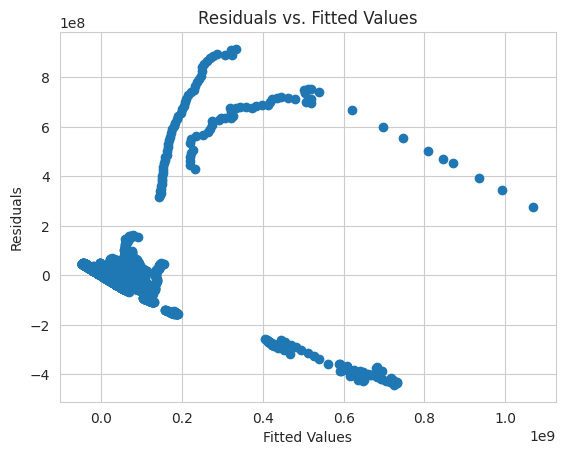

Breusch-Pagan test p-value: 0.0


In [ ]:
#ii Heteroscedasticity
# Check for Heteroscedasticity (unequal variance of residuals)
# Plotting Residuals vs Fitted Values
import statsmodels.stats.api as sms
model = sm.OLS(y, X).fit()
residuals=model.resid
plt.scatter(model.fittedvalues, residuals)
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted Values')
plt.show()

# Breusch-Pagan test for Heteroscedasticity
_, p_value, _, _ = sms.het_breuschpagan(residuals, model.model.exog)

print(f"Breusch-Pagan test p-value: {p_value}")


In [ ]:
# Fit the OLS model with robust standard errors
model_robust = sm.OLS(y, X)
results_robust = model_robust.fit(cov_type='HC3')  # HC3 (heteroskedasticity-consistent covariance matrix estimator type 3) is a common robust covariance estimator

# Print the summary of the model with robust standard errors
results_robust.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Population   R-squared:                       0.435
Model:                            OLS   Adj. R-squared:                  0.434
Method:                 Least Squares   F-statistic:                     80.03
Date:                Wed, 30 Oct 2024   Prob (F-statistic):           9.68e-67
Time:                        18:08:37   Log-Likelihood:            -1.6266e+05
No. Observations:                8277   AIC:                         3.253e+05
Df Residuals:                    8272   BIC:                         3.254e+05
Df Model:                           4                                         
Covariance Type:                  HC3                                         
=================================================================================================
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const                          1.862e+07   1.86e+06      9.994      0.000     1.5e+07    2.23e+07
Arable Land (% of land)        1.362e+06   1.31e+05     10.418      0.000    1.11e+06    1.62e+06
CO2 Emissions (kt)              101.4777     11.083      9.156      0.000      79.755     123.200
Land area (sq. km)               16.0428      1.866      8.597      0.000      12.385      19.700
Urban population (% of total) -6.684e+05   4.88e+04    -13.686      0.000   -7.64e+05   -5.73e+05
==============================================================================
Omnibus:                     8785.879   Durbin-Watson:                   0.034
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           971799.558
Skew:                           5.192   Prob(JB):                         0.00
Kurtosis:                      55.058   Cond. No.                     4.82e+06
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
[2] The condition number is large, 4.82e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Outliers

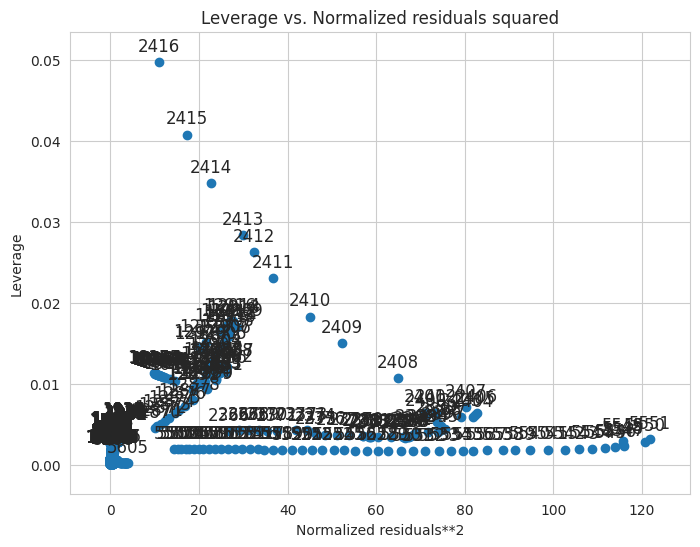

In [ ]:

import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from statsmodels.compat import lzip
from statsmodels.stats.outliers_influence import OLSInfluence
from statsmodels.graphics.regressionplots import plot_leverage_resid2
fig, ax = plt.subplots(figsize=(8,6))
fig = plot_leverage_resid2(model, ax = ax)

Comparing CO2 emissions with the average

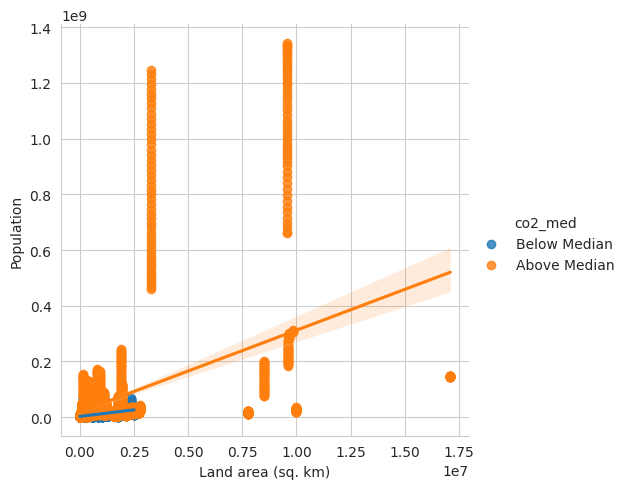

In [ ]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_copy = df.copy()

# Create the 'radio_med' column based on the median of 'CO2 Emissions (kt)'
df_copy['co2_med'] = df_copy['CO2 Emissions (kt)'] > df_copy['CO2 Emissions (kt)'].median()
df_copy['co2_med'] = np.where(df_copy['co2_med'] == False, "Below Median", "Above Median")

# Create the lmplot
sns.lmplot(x='Land area (sq. km)', y='Population', hue='co2_med', data=df_copy)
plt.show()

# **Visuals!**

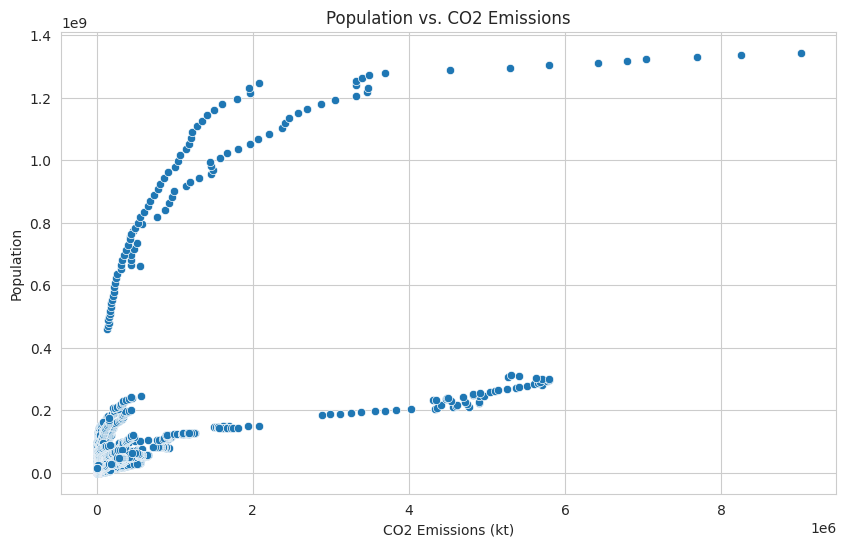

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Scatter plot of Population vs. CO2 Emissions
plt.figure(figsize=(10, 6))
sns.scatterplot(x='CO2 Emissions (kt)', y='Population', data=df)
plt.title('Population vs. CO2 Emissions')
plt.xlabel('CO2 Emissions (kt)')
plt.ylabel('Population')
plt.show()


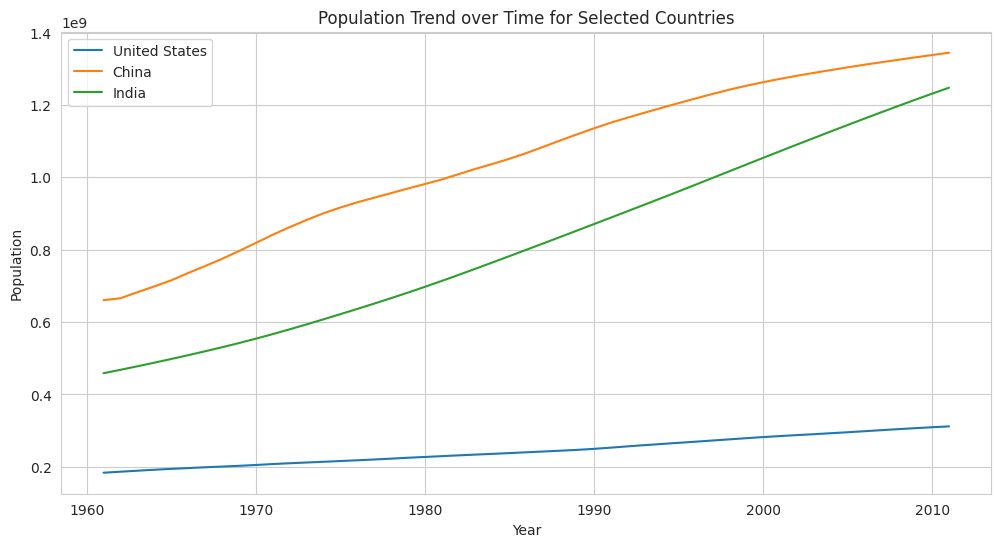

In [ ]:

# 3. Line plot of Population over time for a few selected countries
countries_to_plot = ['United States', 'China', 'India'] #example countries, you can modify
plt.figure(figsize=(12, 6))
for country in countries_to_plot:
    country_data = df[df['CountryName'] == country]
    sns.lineplot(x='Year', y='Population', data=country_data, label=country)
plt.title('Population Trend over Time for Selected Countries')
plt.xlabel('Year')
plt.ylabel('Population')
plt.legend()
plt.show()


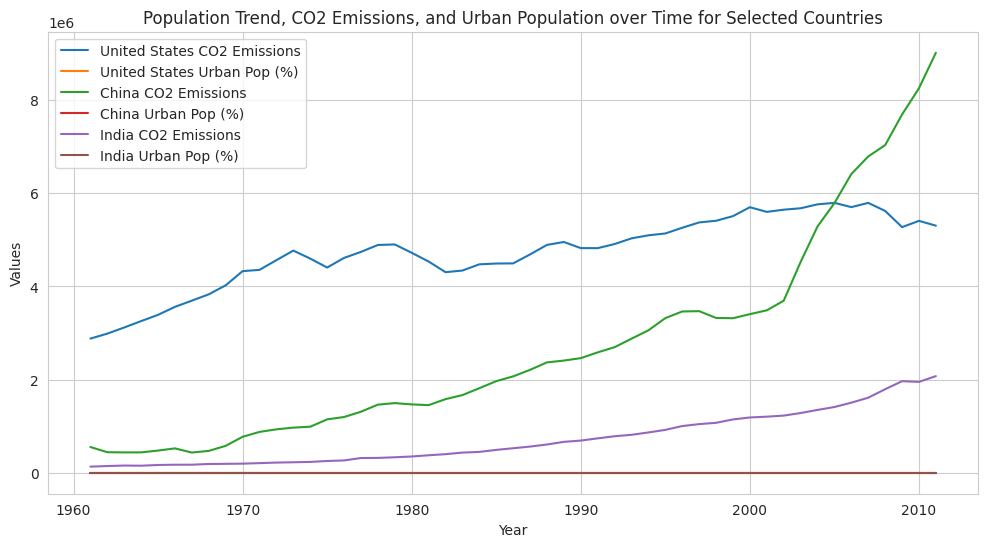

In [ ]:

countries_to_plot = ['United States', 'China', 'India'] #example countries, you can modify
plt.figure(figsize=(12, 6))
for country in countries_to_plot:
    country_data = df[df['CountryName'] == country]
    #  information about CO2 emissions
    sns.lineplot(x='Year', y='CO2 Emissions (kt)', data=country_data, label=f'{country} CO2 Emissions')
    #  information about urban population percentage
    sns.lineplot(x='Year', y='Urban population (% of total)', data=country_data, label=f'{country} Urban Pop (%)')

plt.title('Population Trend, CO2 Emissions, and Urban Population over Time for Selected Countries')
plt.xlabel('Year')
plt.ylabel('Values') # Updated y-axis label for clarity
plt.legend()
plt.show()

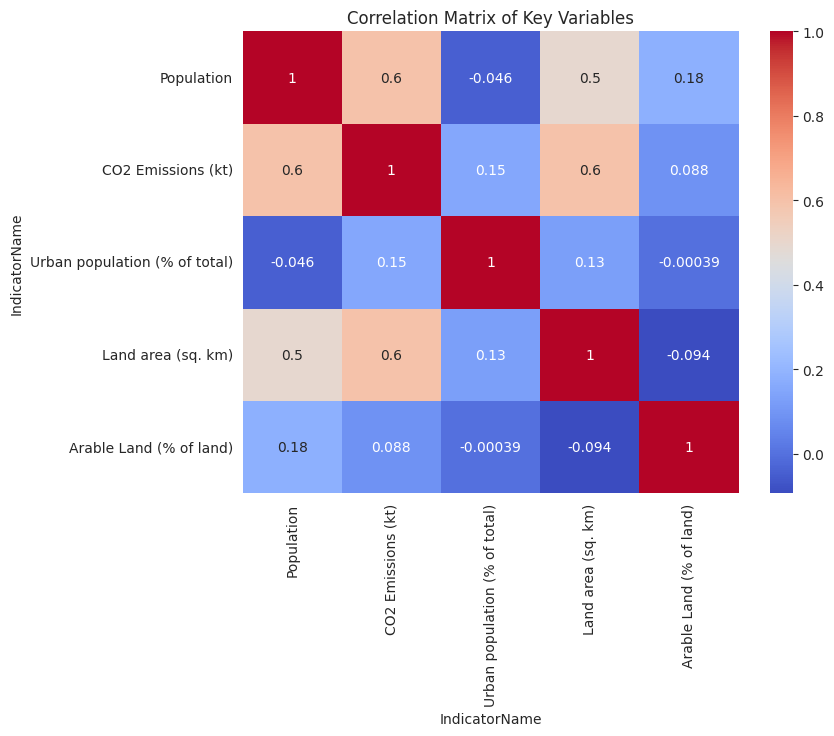

In [ ]:
# 4.  Heatmap of correlation between key variables
corr_matrix = df[['Population', 'CO2 Emissions (kt)', 'Urban population (% of total)', 'Land area (sq. km)', 'Arable Land (% of land)']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Key Variables')
plt.show()

#CO2 Emissions, Land Area, and and Urban Population

In [ ]:
#Relationship between co2 emissions and land area

import plotly.express as px

# Create the scatter plot using plotly.express
fig = px.scatter(df, x='CO2 Emissions (kt)', y='Land area (sq. km)',
                 hover_data=['CountryName', 'Year'],
                 title='Relationship between CO2 Emissions and Land Area',
                 labels={'CO2 Emissions (kt)': 'CO2 Emissions (kt)', 'Land area (sq. km)': 'Land Area (sq. km)'})

fig.show()

In [ ]:
import plotly.express as px


fig = px.bar(df, x="CountryCode", y="CO2 Emissions (kt)", color="CountryCode",
  animation_frame="Year", animation_group="CountryCode", hover_name="CountryCode", range_y=[0,10000000])
fig.show()

In [ ]:
import folium

In [ ]:
url = 'https://raw.githubusercontent.com/python-visualization/folium/master/examples/data'
state_geo = f'{url}/us-states.json' # for US map with state boundaries
world_geo = f'{url}/world-countries.json' # for world map with country boundaries
state_unemployment = f'{url}/US_Unemployment_Oct2012.csv'

In [ ]:
map2 = folium.Map(location=[40, 0], zoom_start=0.5) # [40, 0]: Lattitue, Longitue coordinates of map-center.
filtered_df = df[df['Year'] == 2010]
folium.Choropleth(geo_data=world_geo,
                  data=filtered_df,
             name='choropleth',
             columns=['CountryCode', 'Urban population (% of total)'],
             key_on='feature.id',
             fill_color='YlGnBu', fill_opacity=0.7, line_opacity=0.2,
             legend_name='Urban population (% of total)').add_to(map2)
folium.LayerControl().add_to(map2)
map2